# Phase 2: Exploratory Data Analysis (The 20-Year Narrative)
**Objective:** Before feature engineering or model training, we must understand the macroeconomic reality of the data. 

In this notebook, we analyze the 5 defining economic eras of the 21st century:
1. **2000Q1:** The Dot-Com Boom (High Rates)
2. **2005Q1:** The Subprime Housing Bubble Peak
3. **2008Q1:** The Financial Crisis / Crash
4. **2013Q1:** The Post-Crisis Recovery (Strict Lending)
5. **2020Q1:** The COVID-19 Pandemic (Record Low Rates)

**The Strategy:** We will load the terminal states of these loans (1 row = 1 unique human outcome) across all five cohorts to visualize the chronological evolution of borrower behavior, risk profiles, and feature correlations.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Set professional plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Environment ready for EDA.")

✅ Environment ready for EDA.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Professional plotting style
sns.set_theme(style="whitegrid")

def load_eda_data(file_path, cohort_name):
    """Safely loads data, extracts the terminal state, and labels outcomes."""
    USE_COLS = [1, 2, 7, 9, 12, 15, 22, 23, 25, 26, 27, 28, 29, 30, 43] 
    COL_NAMES = ["LOAN_ID", "ACT_PERIOD", "ORIG_RATE", "UPB", "ORIG_TRM", 
                 "LOAN_AGE", "DTI", "CSCORE_B", "FTHB_FLG", "PURPOSE", 
                 "PROP_TYP", "NUM_UNIT", "OCC_STAT", "STATE", "ZERO_BAL_CODE"]
    
    print(f"⏳ Processing {cohort_name}...")
    chunk_iter = pd.read_csv(
        file_path, sep='|', header=None, usecols=USE_COLS, names=COL_NAMES,
        chunksize=100000, low_memory=False, dtype={"LOAN_ID": str, "ZERO_BAL_CODE": str}
    )
    
    processed_chunks = []
    for chunk in chunk_iter:
        chunk_compressed = chunk.drop_duplicates(subset=["LOAN_ID"], keep="last")
        processed_chunks.append(chunk_compressed)
        del chunk
        gc.collect()

    final_df = pd.concat(processed_chunks).drop_duplicates(subset=["LOAN_ID"], keep="last")
    
    # Label Target
    prepaid_codes = ['01', '1', '1.0']
    final_df["IS_PREPAID"] = np.where(final_df["ZERO_BAL_CODE"].astype(str).str.strip().isin(prepaid_codes), 1, 0)
    final_df["COHORT"] = cohort_name
    
    print(f"✅ {cohort_name} Loaded ({len(final_df):,} loans)")
    return final_df

print("🚀 INITIATING 5-COHORT EXTRACTION (This will take a few minutes)...\n" + "="*50)

# Dictionary of all 5 files
cohort_files = {
    "2000Q1": r"../data/2000Q1.csv",
    "2005Q1": r"../data/2005Q1.csv",
    "2008Q1": r"../data/2008Q1.csv",
    "2013Q1": r"../data/2013Q1.csv",
    "2020Q1": r"../data/2020Q1.csv"
}

# Load them all into a list, then combine
all_cohorts = []
for name, path in cohort_files.items():
    all_cohorts.append(load_eda_data(path, name))

df_eda = pd.concat(all_cohorts, ignore_index=True)

# Convert key numeric columns safely for plotting
for col in ['ORIG_RATE', 'CSCORE_B', 'DTI', 'UPB', 'LOAN_AGE']:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

print("\n" + "="*50)
print(f"🎉 MASTER DATASET READY! Total Loans for EDA: {len(df_eda):,}")

🚀 INITIATING 5-COHORT EXTRACTION (This will take a few minutes)...
⏳ Processing 2000Q1...
✅ 2000Q1 Loaded (246,862 loans)
⏳ Processing 2005Q1...
✅ 2005Q1 Loaded (303,611 loans)
⏳ Processing 2008Q1...
✅ 2008Q1 Loaded (380,832 loans)
⏳ Processing 2013Q1...
✅ 2013Q1 Loaded (681,364 loans)
⏳ Processing 2020Q1...
✅ 2020Q1 Loaded (683,742 loans)

🎉 MASTER DATASET READY! Total Loans for EDA: 2,296,411


### Graph 1: The Chronological Imbalance 
By mapping all five eras, we see that prepayment is not a static probability—it is entirely dependent on the year. This proves why we must undersample our classes *per cohort* in the ETL phase, rather than blending them all together.

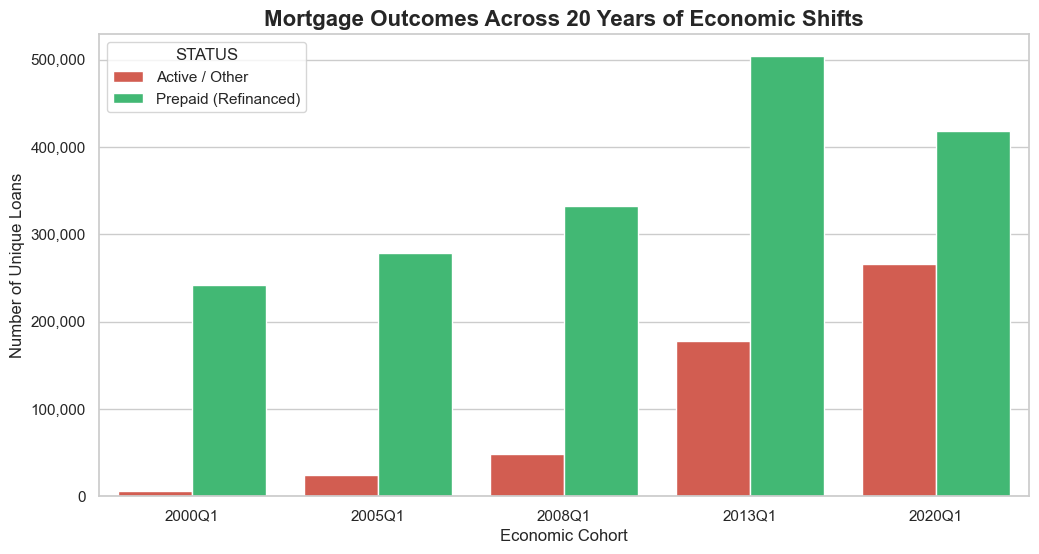

In [11]:
plot_data = df_eda.groupby(['COHORT', 'IS_PREPAID']).size().reset_index(name='COUNT')
plot_data['STATUS'] = plot_data['IS_PREPAID'].map({1: 'Prepaid (Refinanced)', 0: 'Active / Other'})

plt.figure(figsize=(12, 6))
# Using a distinct 5-color palette
ax = sns.barplot(x='COHORT', y='COUNT', hue='STATUS', data=plot_data, palette=['#e74c3c', '#2ecc71'])
plt.title('Mortgage Outcomes Across 20 Years of Economic Shifts', fontsize=16, fontweight='bold')
plt.xlabel('Economic Cohort', fontsize=12)
plt.ylabel('Number of Unique Loans', fontsize=12)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

### Graph 2: The Catalyst (Interest Rate Evolution)
This tracks the steady decline of interest rates over two decades. Notice how the 2000 distribution sits far to the right (~8%), the 2005/2008 bubbles sit in the middle, and the 2013/2020 cohorts hit rock bottom.

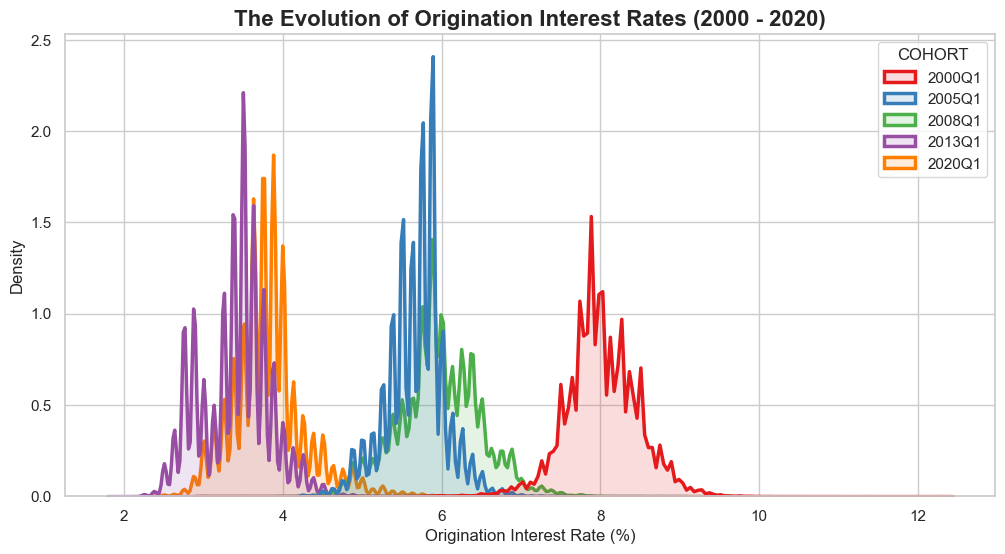

In [12]:
plt.figure(figsize=(12, 6))
# Dropping the fill so 5 overlapping curves remain readable
sns.kdeplot(data=df_eda.dropna(subset=['ORIG_RATE']), x='ORIG_RATE', hue='COHORT', 
            fill=True, alpha=0.15, linewidth=2.5, common_norm=False, palette='Set1')

plt.title('The Evolution of Origination Interest Rates (2000 - 2020)', fontsize=16, fontweight='bold')
plt.xlabel('Origination Interest Rate (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

### Graph 3: The Risk Profile (FICO Evolution)
This is the fingerprint of the 2008 crash. Watch how the FICO scores in 2000 and 2005 are lower and wider (loose lending). Then, suddenly in 2013 and 2020, the boxes shift sharply upward and compress (strict post-crisis lending regulations).

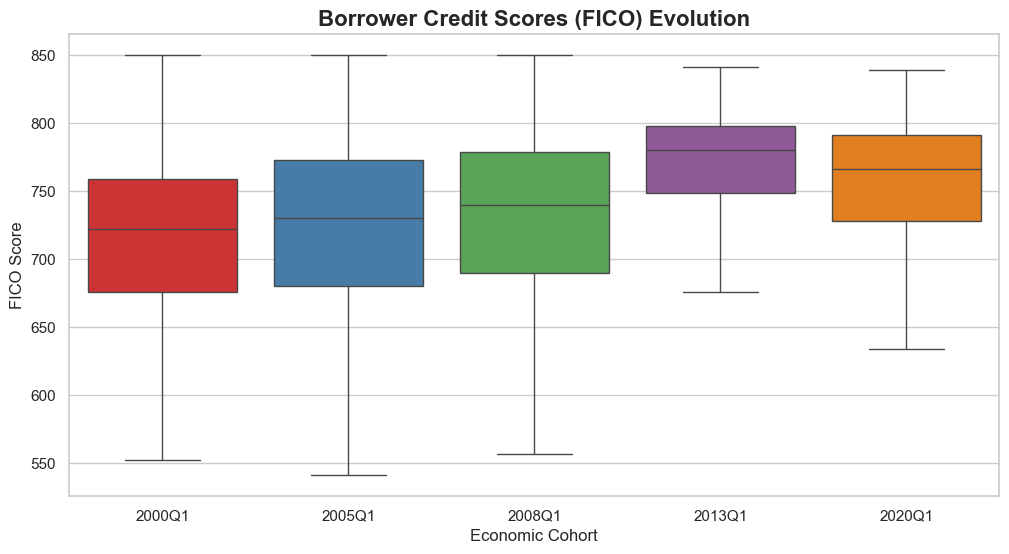

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='COHORT', y='CSCORE_B', hue='COHORT',legend=False,data=df_eda.dropna(subset=['CSCORE_B']), 
            palette='Set1', showfliers=False)

plt.title('Borrower Credit Scores (FICO) Evolution', fontsize=16, fontweight='bold')
plt.xlabel('Economic Cohort', fontsize=12)
plt.ylabel('FICO Score', fontsize=12)
plt.show()

### Graph 4: Borrower Leverage (Debt-to-Income Evolution)
Debt-to-Income (DTI) ratio measures how over-leveraged a borrower is. A standard boxplot would hide the most critical regulatory story in modern banking, which is why we must use a Violin Plot. 

Before the 2008 crash, banks frequently approved loans with dangerous DTIs exceeding 50%. In response to the crash, the US Government passed the **Dodd-Frank Act**, creating the "Qualified Mortgage" (QM) rule which established a strict legal liability limit at a **43% DTI**. 

By using a Violin Plot, we can physically see this regulatory "cliff." Watch how the distributions in the 2013 and 2020 post-crisis cohorts bulge and then violently flatten out right at the 43% regulatory line, completely reshaping borrower leverage compared to the loose lending of the early 2000s.

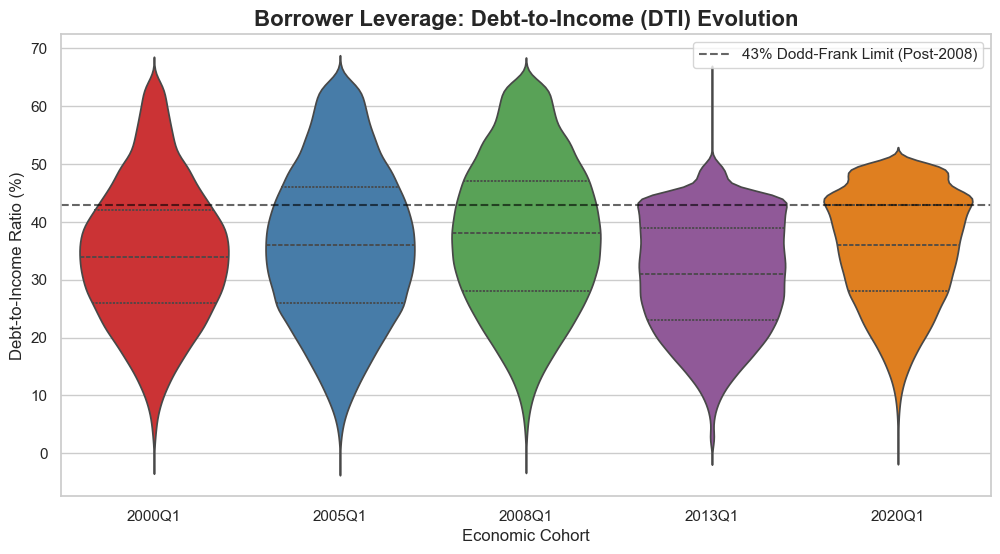

In [20]:
plt.figure(figsize=(12, 6))

# FIX: Forcing 'cut' and 'bw_adjust' to override the stubborn KDE math
sns.violinplot(
    x='COHORT', 
    y='DTI', 
    data=df_eda.dropna(subset=['DTI']), 
    hue='COHORT', 
    palette='Set1', 
    inner="quartile", 
    cut=3,            # Forces the tails to stretch outwards
    bw_adjust=1.5,    # Smooths the curves for that classic textbook shape
    legend=False
)

plt.title('Borrower Leverage: Debt-to-Income (DTI) Evolution', fontsize=16, fontweight='bold')
plt.xlabel('Economic Cohort', fontsize=12)
plt.ylabel('Debt-to-Income Ratio (%)', fontsize=12)

# Adding the regulatory context line
plt.axhline(y=43, color='black', linestyle='--', alpha=0.6, label='43% Dodd-Frank Limit (Post-2008)')
plt.legend()

plt.show()

### Graph 5: Mathematical Foundation (Feature Correlation Heatmap)
Finally, we calculate the correlation matrix across all 20 years of data combined. We safely impute missing values with the median first to ensure our Active (0) loans are not accidentally dropped, preventing mathematical `NaN` failures.

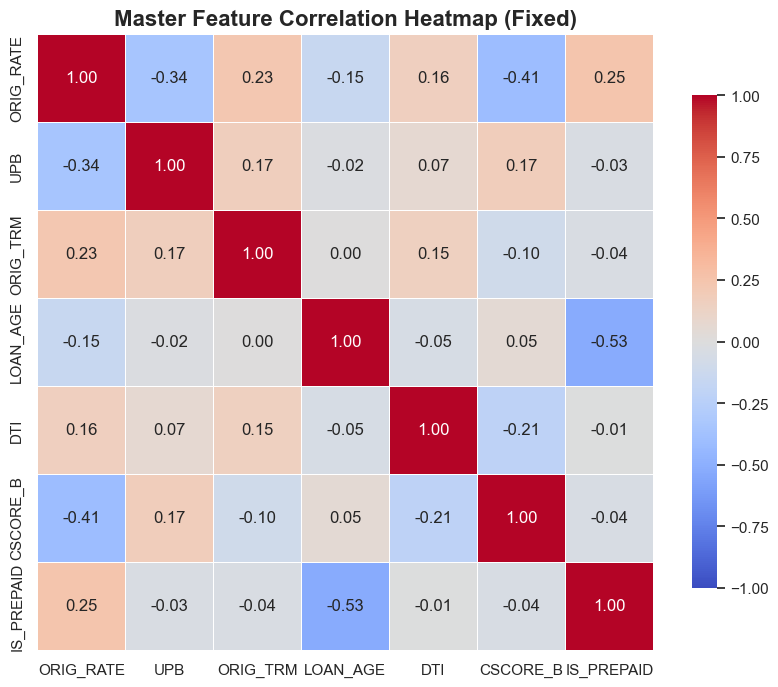

In [15]:
# 1. Select numeric features
numeric_cols = ['ORIG_RATE', 'UPB', 'ORIG_TRM', 'LOAN_AGE', 'DTI', 'CSCORE_B', 'IS_PREPAID']

# 2. Force to numeric
df_numeric = df_eda[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 3. FIX: Fill missing values with median to preserve minority classes!
df_numeric = df_numeric.fillna(df_numeric.median())

# 4. Calculate correlation
corr_matrix = df_numeric.corr()

# 5. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Master Feature Correlation Heatmap (Fixed)', fontsize=16, fontweight='bold')
plt.show()